#**Which features of a job posting are associated with fraud?**

*Dataset source: https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction*




In [1]:
import pandas as pd
import sqlite3

In [2]:
df = pd.read_csv("fake_job_postings.csv")
df.shape

(17880, 18)

In [3]:
df = df[["job_id", "title", "location", "salary_range", "has_company_logo",
         "has_questions", "employment_type", "required_experience",
         "industry", "function", "fraudulent"]]
df.head()

,job_id,title,location,salary_range,has_company_logo,has_questions,employment_type,required_experience,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",NaN,1,0,Other,Internship,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",NaN,1,0,Full-time,Not Applicable,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,1,0,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",NaN,1,0,Full-time,Mid-Senior level,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,1,1,Full-time,Mid-Senior level,Hospital & Health Care,Health Care Provider,0


In [4]:
conn = sqlite3.connect(":memory:")
df.to_sql("postings", conn, index=False)


17880

## Baseline: how many postings are fraudulent?

In [5]:
pd.read_sql("""
SELECT fraudulent, COUNT(*) AS n_postings
FROM postings
GROUP BY fraudulent
""", conn)

,fraudulent,n_postings
0,0,17014
1,1,866


- 866 of 17,880 postings (4.8%) are fraudulent. This is the baseline the signals below are compared against.

## Signal 1: company logo

In [6]:
pd.read_sql("""
SELECT has_company_logo,
       COUNT(*) AS postings_count,
       ROUND(AVG(fraudulent) * 100, 1) AS fraud_pct
FROM postings
GROUP BY has_company_logo
""", conn)

,has_company_logo,postings_count,fraud_pct
0,0,3660,15.9
1,1,14220,2.0


- Out of all the postings with a logo, 2% are fraudulent.

- Out of all the postings without a logo, 15.9% are fraudulent.

**Postings without a logo are about eight times more likely to be fraudulent.**

In [7]:
pd.read_sql("""
SELECT 'logo' AS logo_status, COUNT(*) AS n_fraudulent, ROUND(COUNT(*) * 100.0/866, 1) AS pct_of_fraud
FROM postings
WHERE has_company_logo = 1 AND fraudulent = 1
UNION ALL
SELECT 'no logo', COUNT(*), ROUND(COUNT(*) * 100.0/866, 1) AS pct_of_fraud
FROM postings
WHERE has_company_logo = 0 AND fraudulent = 1
""", conn)

,logo_status,n_fraudulent,pct_of_fraud
0,logo,283,32.7
1,no logo,583,67.3


- 67.3% of fraudulent postings have no logo (583 of 866).
- 32.7% of fraudulent postings have a logo (283 of 866).

**A missing logo is a useful risk signal but not enough on its own: about two-thirds of fraudulent postings have no logo, yet most postings without a logo (84%) are legitimate.**

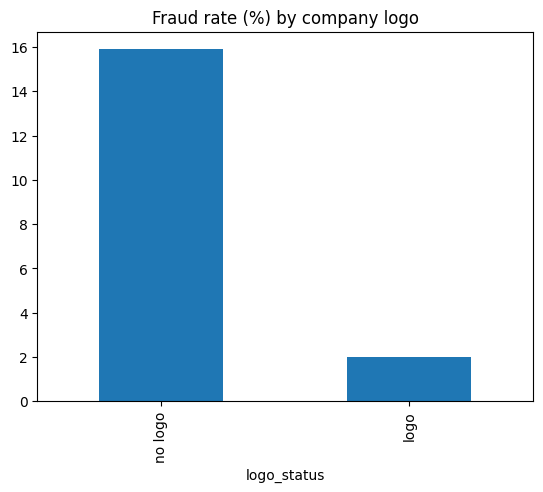

In [8]:
logo = pd.read_sql("""
SELECT CASE WHEN has_company_logo = 1 THEN 'logo' ELSE 'no logo' END AS logo_status,
       ROUND(AVG(fraudulent) * 100, 1) AS fraud_pct
FROM postings
GROUP BY has_company_logo
""", conn)

logo.plot.bar(x="logo_status", y="fraud_pct", legend=False,
              title="Fraud rate (%) by company logo");

## Signal 2: unspecified industry

In [9]:
pd.read_sql("""
SELECT industry, COUNT(*) AS n_fraudulent,
    ROUND(COUNT(*) * 100.0/17880, 1) AS pct_of_all_postings,
    ROUND(COUNT(*) * 100.0/866, 1) AS pct_of_fraud
FROM postings
WHERE fraudulent = 1
GROUP BY industry
ORDER BY n_fraudulent DESC
LIMIT 10
""", conn)

,industry,n_fraudulent,pct_of_all_postings,pct_of_fraud
0,None,275,1.5,31.8
1,Oil & Energy,109,0.6,12.6
2,Accounting,57,0.3,6.6
3,Hospital & Health Care,51,0.3,5.9
4,Marketing and Advertising,45,0.3,5.2
5,Financial Services,35,0.2,4.0
6,Information Technology and Services,32,0.2,3.7
7,Telecommunications,26,0.1,3.0
8,Real Estate,24,0.1,2.8
9,Consumer Services,24,0.1,2.8


- Out of all listings, fraudulent listings in each specified industry make up less than 1%, while fraudulent listings with an unspecified industry make up 1.5%.
- Out of all fraudulent listings, 31.8% have an unspecified industry.



In [10]:
pd.read_sql("""
SELECT COUNT(*) AS n_postings,
    ROUND(AVG(fraudulent) * 100, 1) AS fraud_pct
FROM postings
WHERE industry IS NULL
""", conn)

,n_postings,fraud_pct
0,4903,5.6


- Out of all postings with unspecified industry, 5.6% are fraudulent.

**Although almost one-third of fraudulent listings have an unspecified industry, so do many legitimate ones, which makes unspecified industry an unreliable indicator.**




## Combined: no logo and no industry

In [11]:
pd.read_sql("""
SELECT COUNT(*) as no_logo_no_industry_fraud,
    ROUND(COUNT(*) * 100.0/866, 1) AS pct_of_fraud
FROM postings
WHERE fraudulent = 1 AND has_company_logo = 0 AND industry IS NULL
""", conn)

,no_logo_no_industry_fraud,pct_of_fraud
0,237,27.4


- 27.4% of all fraudulent listings have neither a logo nor a specified industry (237 of 866).
- Of fraudulent listings with an unspecified industry, most (237 out of 275) also have no logo.

In [12]:
pd.read_sql("""
SELECT COUNT(*) AS n_postings,
    ROUND(AVG(fraudulent) * 100, 1) AS fraud_pct
FROM postings
WHERE has_company_logo = 0 AND industry IS NULL
""", conn)

,n_postings,fraud_pct
0,1447,16.4


- Of all postings with neither a logo nor a specified industry, 16.4% are fraudulent (237 of 1,447), compared with 15.9% for postings without a logo alone.

**Adding a missing industry to a missing logo barely changes the fraud rate, so it adds little as a combined signal.**

## Conclusion

- A missing logo is the strongest signal tested: 15.9% of postings without a logo are fraudulent, compared with 2.0% with one.
- An unspecified industry is an unreliable signal on its own (5.6%, against a 4.8% baseline), and adds little when combined with a missing logo (16.4%).

**Limitations**
- The data comes from one recruitment platform and is over a decade old; scam patterns have changed since.
- The fraud labels reflect what that platform caught, so some fraud may be labelled as legitimate.
- These signals indicate risk and could prioritise postings for review, but they don't prove fraud on their own.